# Import Libraries

In [12]:
import pandas as pd
import sys
sys.path.append('..')
from src.load_data import load_data
from src.date import normalize_dates
from src.plot import correlation_map
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
%matplotlib inline

# Load Datasets

In [2]:
news = load_data('../data/raw_analyst_ratings.csv')
aapl_price = load_data('../data/AAPL.csv')
amzn_price = load_data('../data/AMZN.csv')
goog_price = load_data('../data/GOOG.csv')
meta_price = load_data('../data/META.csv')
msft_price = load_data('../data/MSFT.csv')
nvda_price = load_data('../data/NVDA.csv')

In [3]:
# put all prices datasets in to a list
price_files = [aapl_price, amzn_price, goog_price, meta_price, msft_price, nvda_price]
stock_names = ['AAPL-STOCK', 'AMZN-STOCK', 'GOOG-STOCK', 'META-STOCK', 'MSFT-STOCK', 'NVDA-STOCK']
for file, stock_name in zip(price_files, stock_names):
    file.rename(columns={'Close':f'Close_{stock_name}'}, inplace=True)

# Clean & Normalize Dates

In [4]:
news = news.reset_index(drop=True)
news.rename(columns={'date': 'Date'}, inplace=True)
news['Date'] = normalize_dates(news['Date'])
cleaned_stocks = []
for file in price_files:
    file['Date'] = normalize_dates(file['Date'])
    cleaned_stocks.append(file)


In [5]:
merged = news[['headline','Date']].copy()
for stock_name, file in zip(stock_names, cleaned_stocks):
    file = file[['Date', f'Close_{stock_name}']]
    merged = merged.merge(file, on='Date', how='left')
merged

,headline,Date,Close_AAPL-STOCK,Close_AMZN-STOCK,Close_GOOG-STOCK,Close_META-STOCK,Close_MSFT-STOCK,Close_NVDA-STOCK
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05,80.390961,124.150002,71.430679,229.356110,179.059250,8.890193
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03,78.843788,123.919998,71.330872,228.749817,177.299301,8.736208
2,71 Biggest Movers From Friday,2020-05-26,76.809151,121.093002,70.369438,230.777313,173.674103,8.684656
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984
...,...,...,...,...,...,...,...,...
1407323,Top Narrow Based Indexes For August 29,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1407324,Recap: Wednesday's Top Percentage Gainers and ...,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1407325,UPDATE: Oppenheimer Color on China Zenix Auto ...,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1407326,Oppenheimer Initiates China Zenix At Outperfor...,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# List of all stock columns
stock_cols = ['Close_AAPL-STOCK','Close_AMZN-STOCK','Close_GOOG-STOCK',
              'Close_META-STOCK','Close_MSFT-STOCK','Close_NVDA-STOCK']

# Keep only rows where at least one stock has data
mearged = merged.dropna(subset=stock_cols, how='all')
for col in stock_cols:
    merged[col] = merged[col].fillna(mearged[col].mean())

# Sentiment Analysis

In [7]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [8]:
vader_sentiment = SentimentIntensityAnalyzer()
def compute_sentiment(text):
    if pd.isna(text):
        text = ''
    score = vader_sentiment.polarity_scores(text)
    return score['compound']

In [9]:
merged['sentiment'] = merged['headline'].apply(compute_sentiment)
merged.head(10)

,headline,Date,Close_AAPL-STOCK,Close_AMZN-STOCK,Close_GOOG-STOCK,Close_META-STOCK,Close_MSFT-STOCK,Close_NVDA-STOCK,sentiment
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05,80.390961,124.150002,71.430679,229.356110,179.059250,8.890193,0.000
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03,78.843788,123.919998,71.330872,228.749817,177.299301,8.736208,0.000
2,71 Biggest Movers From Friday,2020-05-26,76.809151,121.093002,70.369438,230.777313,173.674103,8.684656,0.000
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984,0.000
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984,0.296
5,"CFRA Maintains Hold on Agilent Technologies, L...",2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984,-0.128
6,"UBS Maintains Neutral on Agilent Technologies,...",2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984,0.000
7,Agilent Technologies shares are trading higher...,2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984,0.296
8,Wells Fargo Maintains Overweight on Agilent Te...,2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984,-0.128
9,10 Biggest Price Target Changes For Friday,2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984,0.000


# Calculate Daily Stock Returns

In [10]:
for col in stock_cols:
    merged[f'{col}_Return'] = merged[col].pct_change()
merged.head()

,headline,Date,Close_AAPL-STOCK,Close_AMZN-STOCK,Close_GOOG-STOCK,Close_META-STOCK,Close_MSFT-STOCK,Close_NVDA-STOCK,sentiment,Close_AAPL-STOCK_Return,Close_AMZN-STOCK_Return,Close_GOOG-STOCK_Return,Close_META-STOCK_Return,Close_MSFT-STOCK_Return,Close_NVDA-STOCK_Return
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05,80.390961,124.150002,71.430679,229.356110,179.059250,8.890193,0.000,NaN,NaN,NaN,NaN,NaN,NaN
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03,78.843788,123.919998,71.330872,228.749817,177.299301,8.736208,0.000,-0.019246,-0.001853,-0.001397,-0.002643,-0.009829,-0.017321
2,71 Biggest Movers From Friday,2020-05-26,76.809151,121.093002,70.369438,230.777313,173.674103,8.684656,0.000,-0.025806,-0.022813,-0.013479,0.008863,-0.020447,-0.005901
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984,0.000,0.006820,0.006202,-0.004658,0.011671,0.010685,0.035387
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22,77.332962,121.844002,70.041687,233.470718,175.529724,8.991984,0.296,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Correlation Analysis Between Sentiment and Returns

In [11]:
return_col = [f'{col}_Return' for col in stock_cols]
correlation = merged[['sentiment'] + return_col].corr()
correlation

,sentiment,Close_AAPL-STOCK_Return,Close_AMZN-STOCK_Return,Close_GOOG-STOCK_Return,Close_META-STOCK_Return,Close_MSFT-STOCK_Return,Close_NVDA-STOCK_Return
sentiment,1.000000,0.003072,0.003591,0.003611,0.002690,0.003640,0.003903
Close_AAPL-STOCK_Return,0.003072,1.000000,0.931888,0.938699,0.466528,0.968348,0.890581
Close_AMZN-STOCK_Return,0.003591,0.931888,1.000000,0.961311,0.517137,0.975416,0.960835
Close_GOOG-STOCK_Return,0.003611,0.938699,0.961311,1.000000,0.500910,0.963142,0.907651
Close_META-STOCK_Return,0.002690,0.466528,0.517137,0.500910,1.000000,0.540545,0.602438
Close_MSFT-STOCK_Return,0.003640,0.968348,0.975416,0.963142,0.540545,1.000000,0.949911
Close_NVDA-STOCK_Return,0.003903,0.890581,0.960835,0.907651,0.602438,0.949911,1.000000


# Quick Visualization

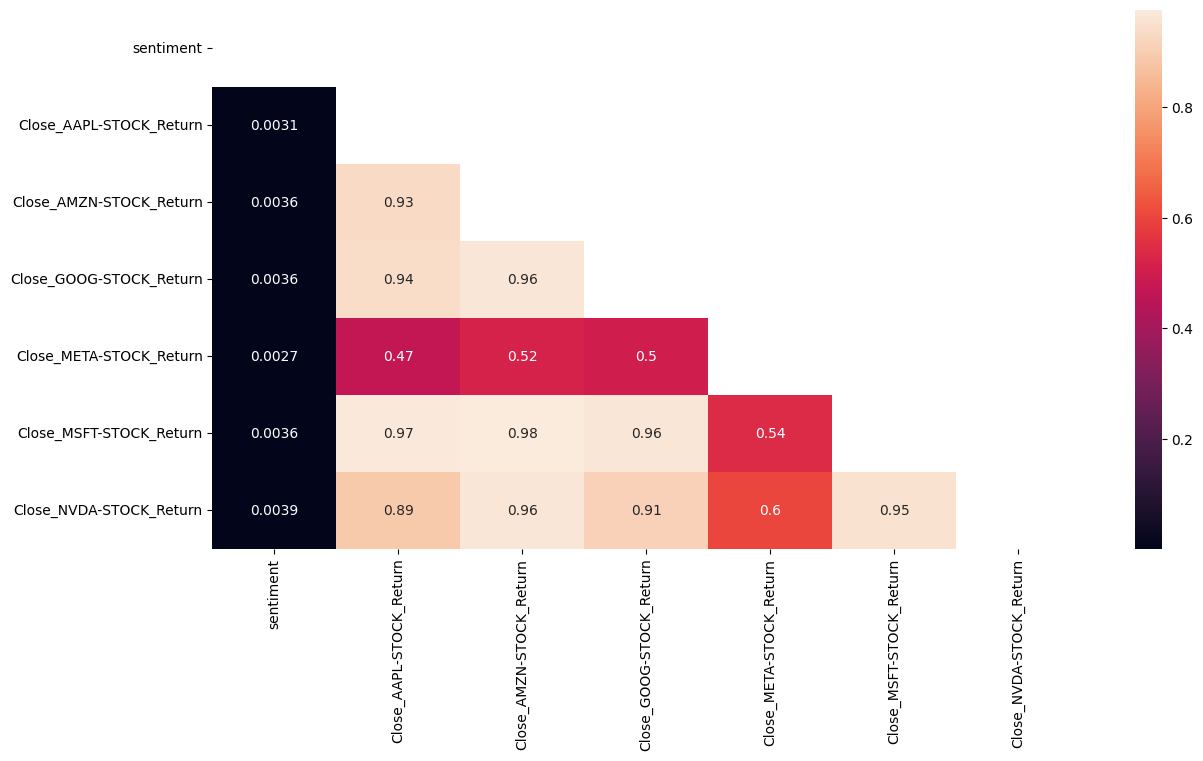

In [13]:
correlation_map(correlation)